# 05 — Sleep × cycle phase natural experiment (Fig 4, S14)

Reproduces Fig 4 (a, b, c) and S14: per-cycle-phase analysis of acute sleep
duration changes (`acr_sleep_dur`) on physiology (RHR, HRV, RR, skin temp,
blood O₂) within the natural-experiment subset (subjects with chronic sleep
between 7 and 8 hours/night).

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from menstrual_cycle_analysis import (
    CycleLengthAnalyses,
    PhysioBehaviorAnalyses,
    PhysioMethods,
    load_paper_data,
)

np.random.seed(42)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

## Setup

Construct two `PhysioBehaviorAnalyses` instances. The first one
(default `physio_prefix='pct'`) is built only for its side effect on `PM`:
its constructor adds workout, sleep, seasonality, acute/chronic behavior,
and menstrual-phase columns to `PM.data` and `PM.reference_table`. We
discard it. After running `process_physio_data` again with the
`'behavioral'` filter preset (which adds `pct_behavioral_*` columns),
the second PBA is the one we use for the figures and stats.

In [ ]:
day_df, CBM = load_paper_data()
CBM.add_sleep_behaviors('user')
CBM.add_workout_behaviors('user')
CBM.add_sleep_behaviors('cycle')
CBM.add_workout_behaviors('cycle')
cla = CycleLengthAnalyses(CBM=CBM)
PM = PhysioMethods(cbm=CBM)
PM.get_reference_table()
PM.process_physio_data(overwrite=True)
_ = PhysioBehaviorAnalyses(cla=cla, pm=PM)        # discard; only here for side effects on PM
PM.process_physio_data(preset='behavioral', prefix='behavioral', types=['pct'], overwrite=True)
PBA = PhysioBehaviorAnalyses(cla=cla, pm=PM, physio_prefix='pct_behavioral')
print('PBA initialised')

## Fig 4a — sleep duration change histograms by phase

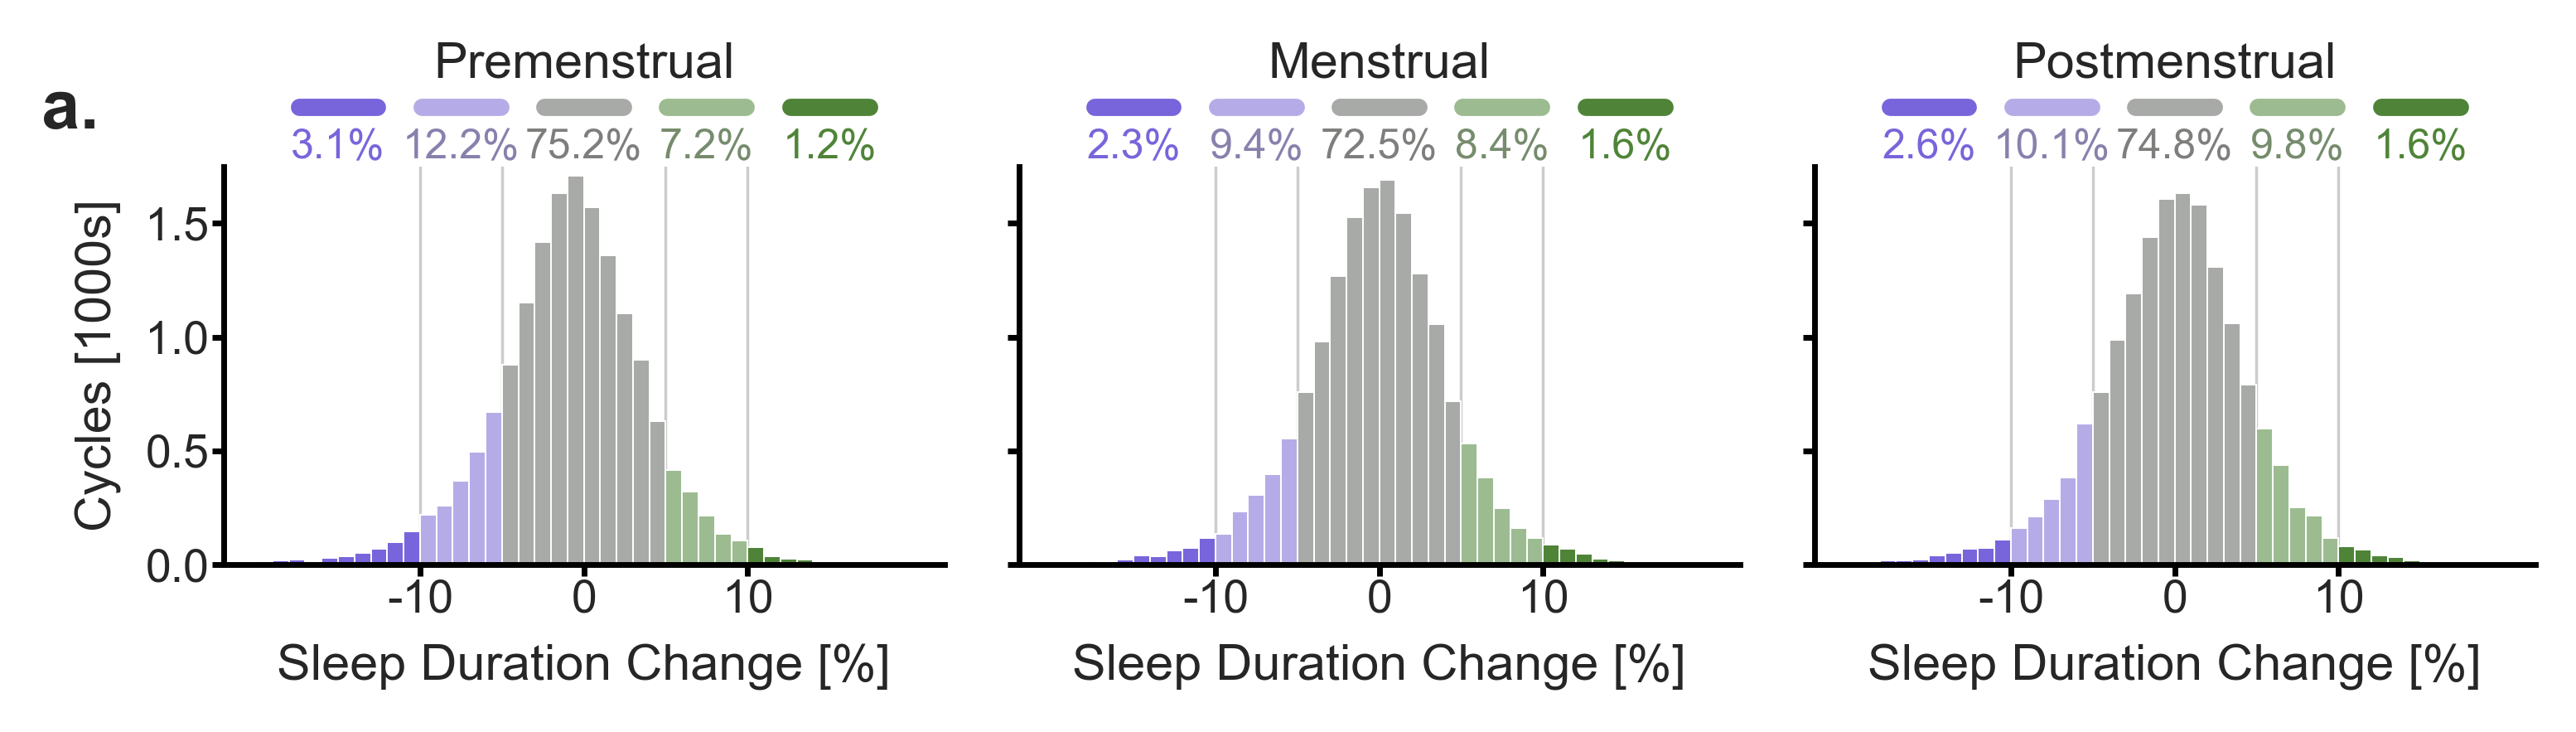

In [3]:
f, axes = PBA.plot_phase_behav_change(behav_var='acr_sleep_dur', figure_label='a.', save_fig=False)
plt.show()

## Phase × behavior-change stats

Cohort: 2,312 subjects / 47,702 observations / 20,814 cycles.
Premenstrual large-decrease reverse OR ≈ 1.39 [95% CI 1.14, 1.68]
(matches the Figure 4 caption).

In [4]:
PBA.phase_behav_change_stats()

Number of subjects: 2312
Number of observations: 47702
Number of cycles: 20814
Calculating mean difference model for acr_sleep_dur across phases


                              0              1              2
term                      phase          phase          phase
value1             premenstrual   premenstrual      menstrual
value2                menstrual  postmenstrual  postmenstrual
mean1                     -1.11          -1.11           -0.4
mean2                      -0.4          -0.29          -0.29
contrast                   0.71           0.81           0.11
contrast_linear            0.71           0.81           0.11
contrast_se                0.05           0.06           0.05
contrast_ci_lower          0.61            0.7           0.01
contrast_ci_upper          0.81           0.92            0.2

Mean sleep duration change difference across phases in minutes
0    3.173666
1    3.662399
2    0.488733
Name: contrast, dtype: float64
------------------

Calculating large decrease model for acr_sleep_dur across phases


                              0              1              2
term                      phase          phase          phase
value1             premenstrual   premenstrual      menstrual
value2                menstrual  postmenstrual  postmenstrual
mean1                    0.0173         0.0173         0.0125
mean2                    0.0125          0.013          0.013
contrast                -0.0048        -0.0044         0.0004
contrast_linear         -0.3295        -0.2966          0.033
contrast_se              0.0709         0.0686         0.0721
contrast_ci_lower       -0.4685         -0.431        -0.1083
contrast_ci_upper       -0.1906        -0.1622         0.1742
odds_ratio               0.7192         0.7433         1.0335
ci_l_or                  0.5934         0.6154         0.8471
ci_u_or                  0.8718         0.8979         1.2609
Reverse odds
                   0         1         2
odds_ratio  1.390434  1.345352  0.967586
ci_l_or     1.685204  1.624959  1.180

                              0              1              2
term                      phase          phase          phase
value1             premenstrual   premenstrual      menstrual
value2                menstrual  postmenstrual  postmenstrual
mean1                    0.0094         0.0094         0.0136
mean2                    0.0136         0.0116         0.0116
contrast                 0.0042         0.0022         -0.002
contrast_linear           0.377         0.2147        -0.1623
contrast_se              0.0986         0.1054         0.0959
contrast_ci_lower        0.1837         0.0082        -0.3503
contrast_ci_upper        0.5702         0.4212         0.0257
odds_ratio               1.4579         1.2395         0.8502
ci_l_or                  1.1655         0.9823         0.6883
ci_u_or                  1.8236          1.564         1.0501
Reverse odds
                   0         1         2
odds_ratio  0.685918  0.806777  1.176194
ci_l_or     0.858001  1.018019  1.452

## Per-biometric models

One GEE per biometric. Cardiorespiratory: 2,312 / 47,692 / 20,806;
skin temp: 2,288 / 40,441 / 17,927.

In [5]:
PBA.get_physio_behav_change_models(behav_var='acr_sleep_dur', physio_prefix='pct_behavioral')


--------------------
Fitting model for RHR:
Number of subjects: 2312
Number of observations: 47692
Number of cycles: 20806
---------------------




--------------------
Fitting model for HRV:
Number of subjects: 2312
Number of observations: 47692
Number of cycles: 20806
---------------------




--------------------
Fitting model for RR:
Number of subjects: 2312
Number of observations: 47692
Number of cycles: 20806
---------------------




--------------------
Fitting model for skin_temp:
Number of subjects: 2288
Number of observations: 40441
Number of cycles: 17927
---------------------




--------------------
Fitting model for blood_oxygen:
Number of subjects: 2287
Number of observations: 40418
Number of cycles: 17918
---------------------



{'RHR': <statsmodels.genmod.generalized_estimating_equations.GEEResultsWrapper at 0x147c61420>,
 'HRV': <statsmodels.genmod.generalized_estimating_equations.GEEResultsWrapper at 0x1501e7d90>,
 'RR': <statsmodels.genmod.generalized_estimating_equations.GEEResultsWrapper at 0x4be11bd60>,
 'skin_temp': <statsmodels.genmod.generalized_estimating_equations.GEEResultsWrapper at 0x3d3563d30>,
 'blood_oxygen': <statsmodels.genmod.generalized_estimating_equations.GEEResultsWrapper at 0x3d3563910>}

## Fig 4c — RHR vs sleep change, by phase

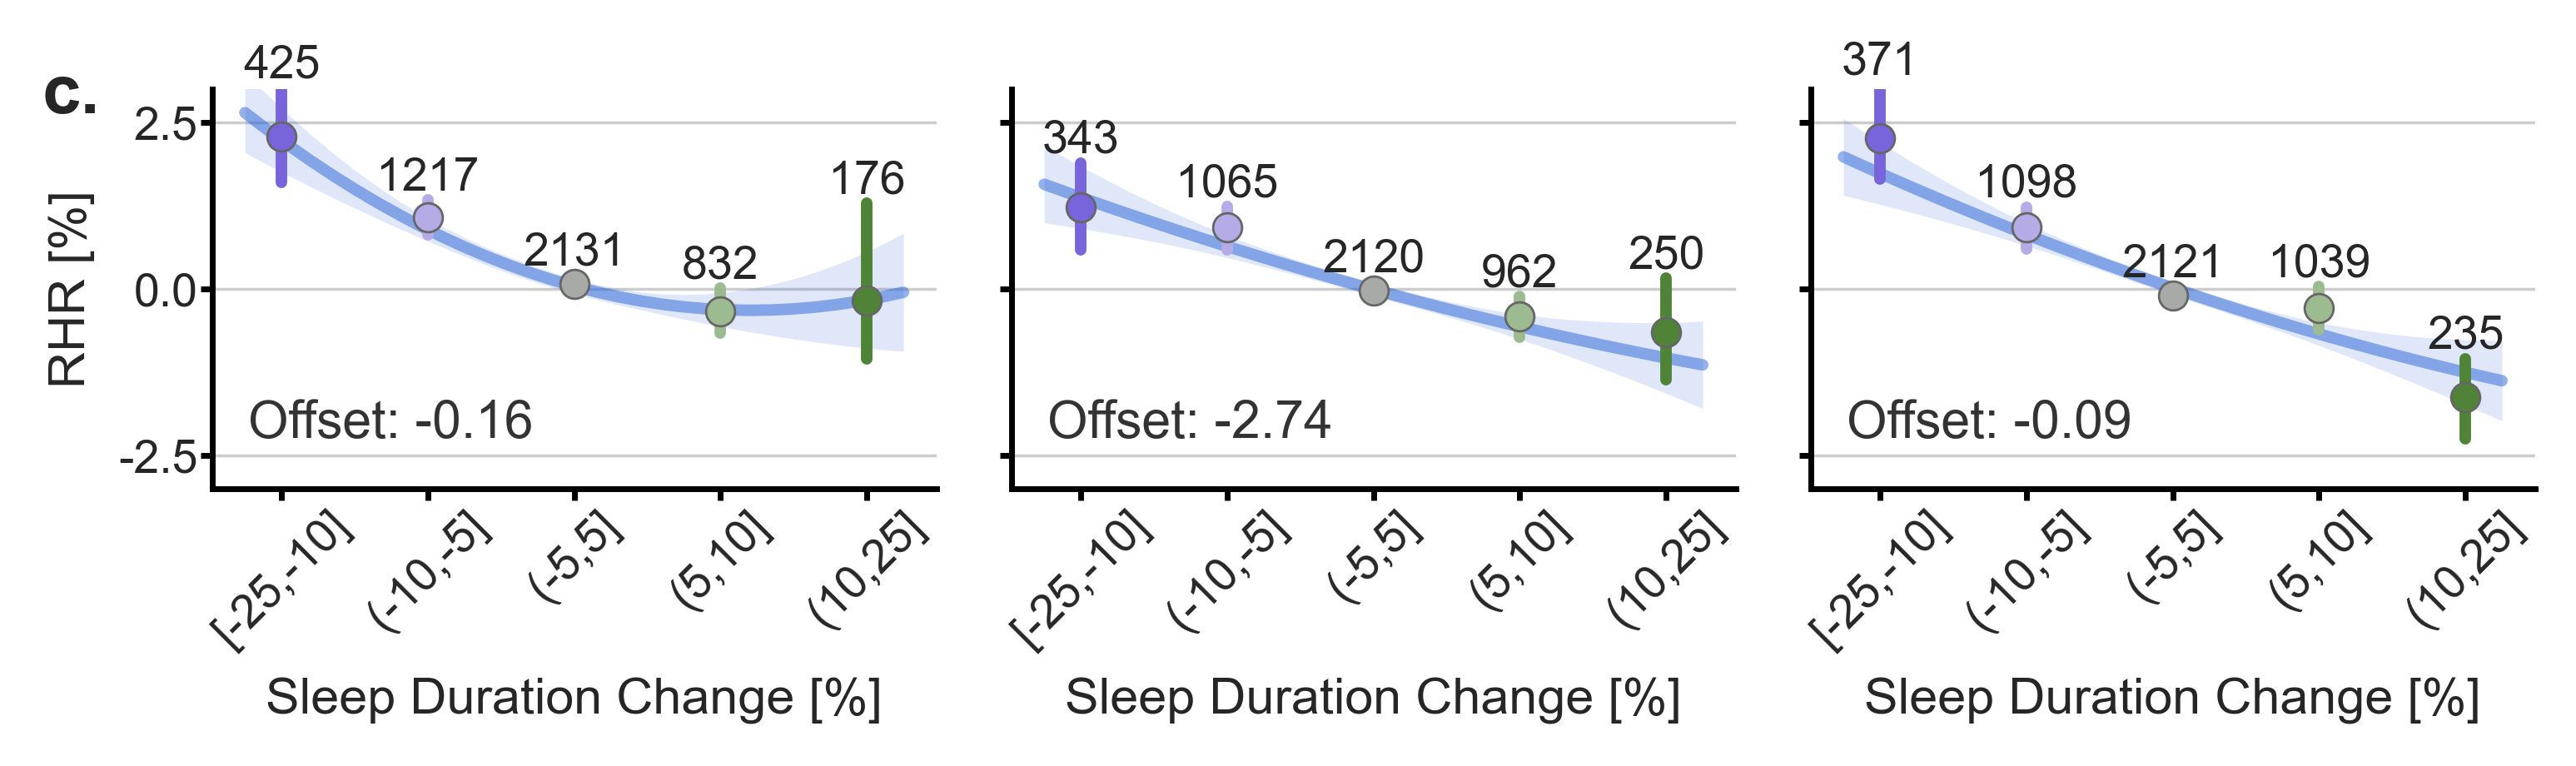

In [6]:
PBA.f_label_buffer = 0.025
f, axes = PBA.plot_model_physio_response_x_phase(physio_var='RHR', save=False, figure_label='c.')
plt.show()

## Fig 4b — RHR by cycle day, by phase

/Users/alex/Documents/Research/WHOOP/menstrual_cycle_physiology_sleep_whoop/menstrual_cycle_analysis/physio_methods.py:2611: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(yticklabels)


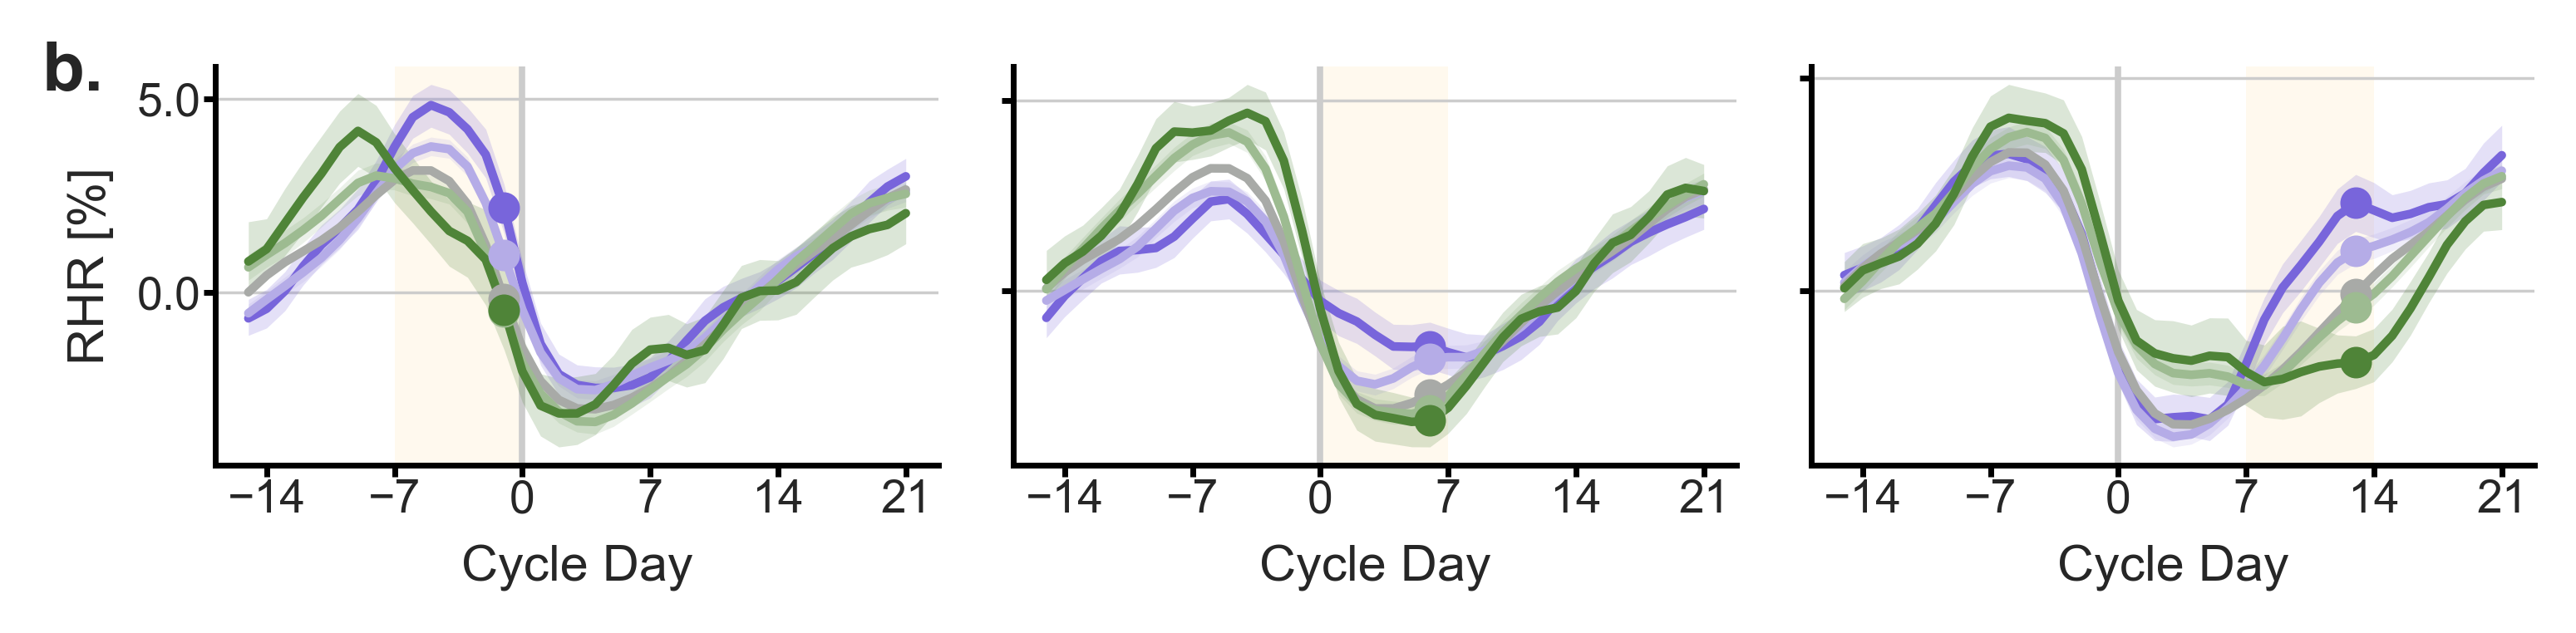

In [7]:
f, axes = PBA.plot_physio_behav_change_by_phase_continous(behav_var='acr_sleep_dur', physio_var='RHR', figure_label='b.', save_fig=False)
plt.show()

## Fig S14 — all biometrics × phase grid

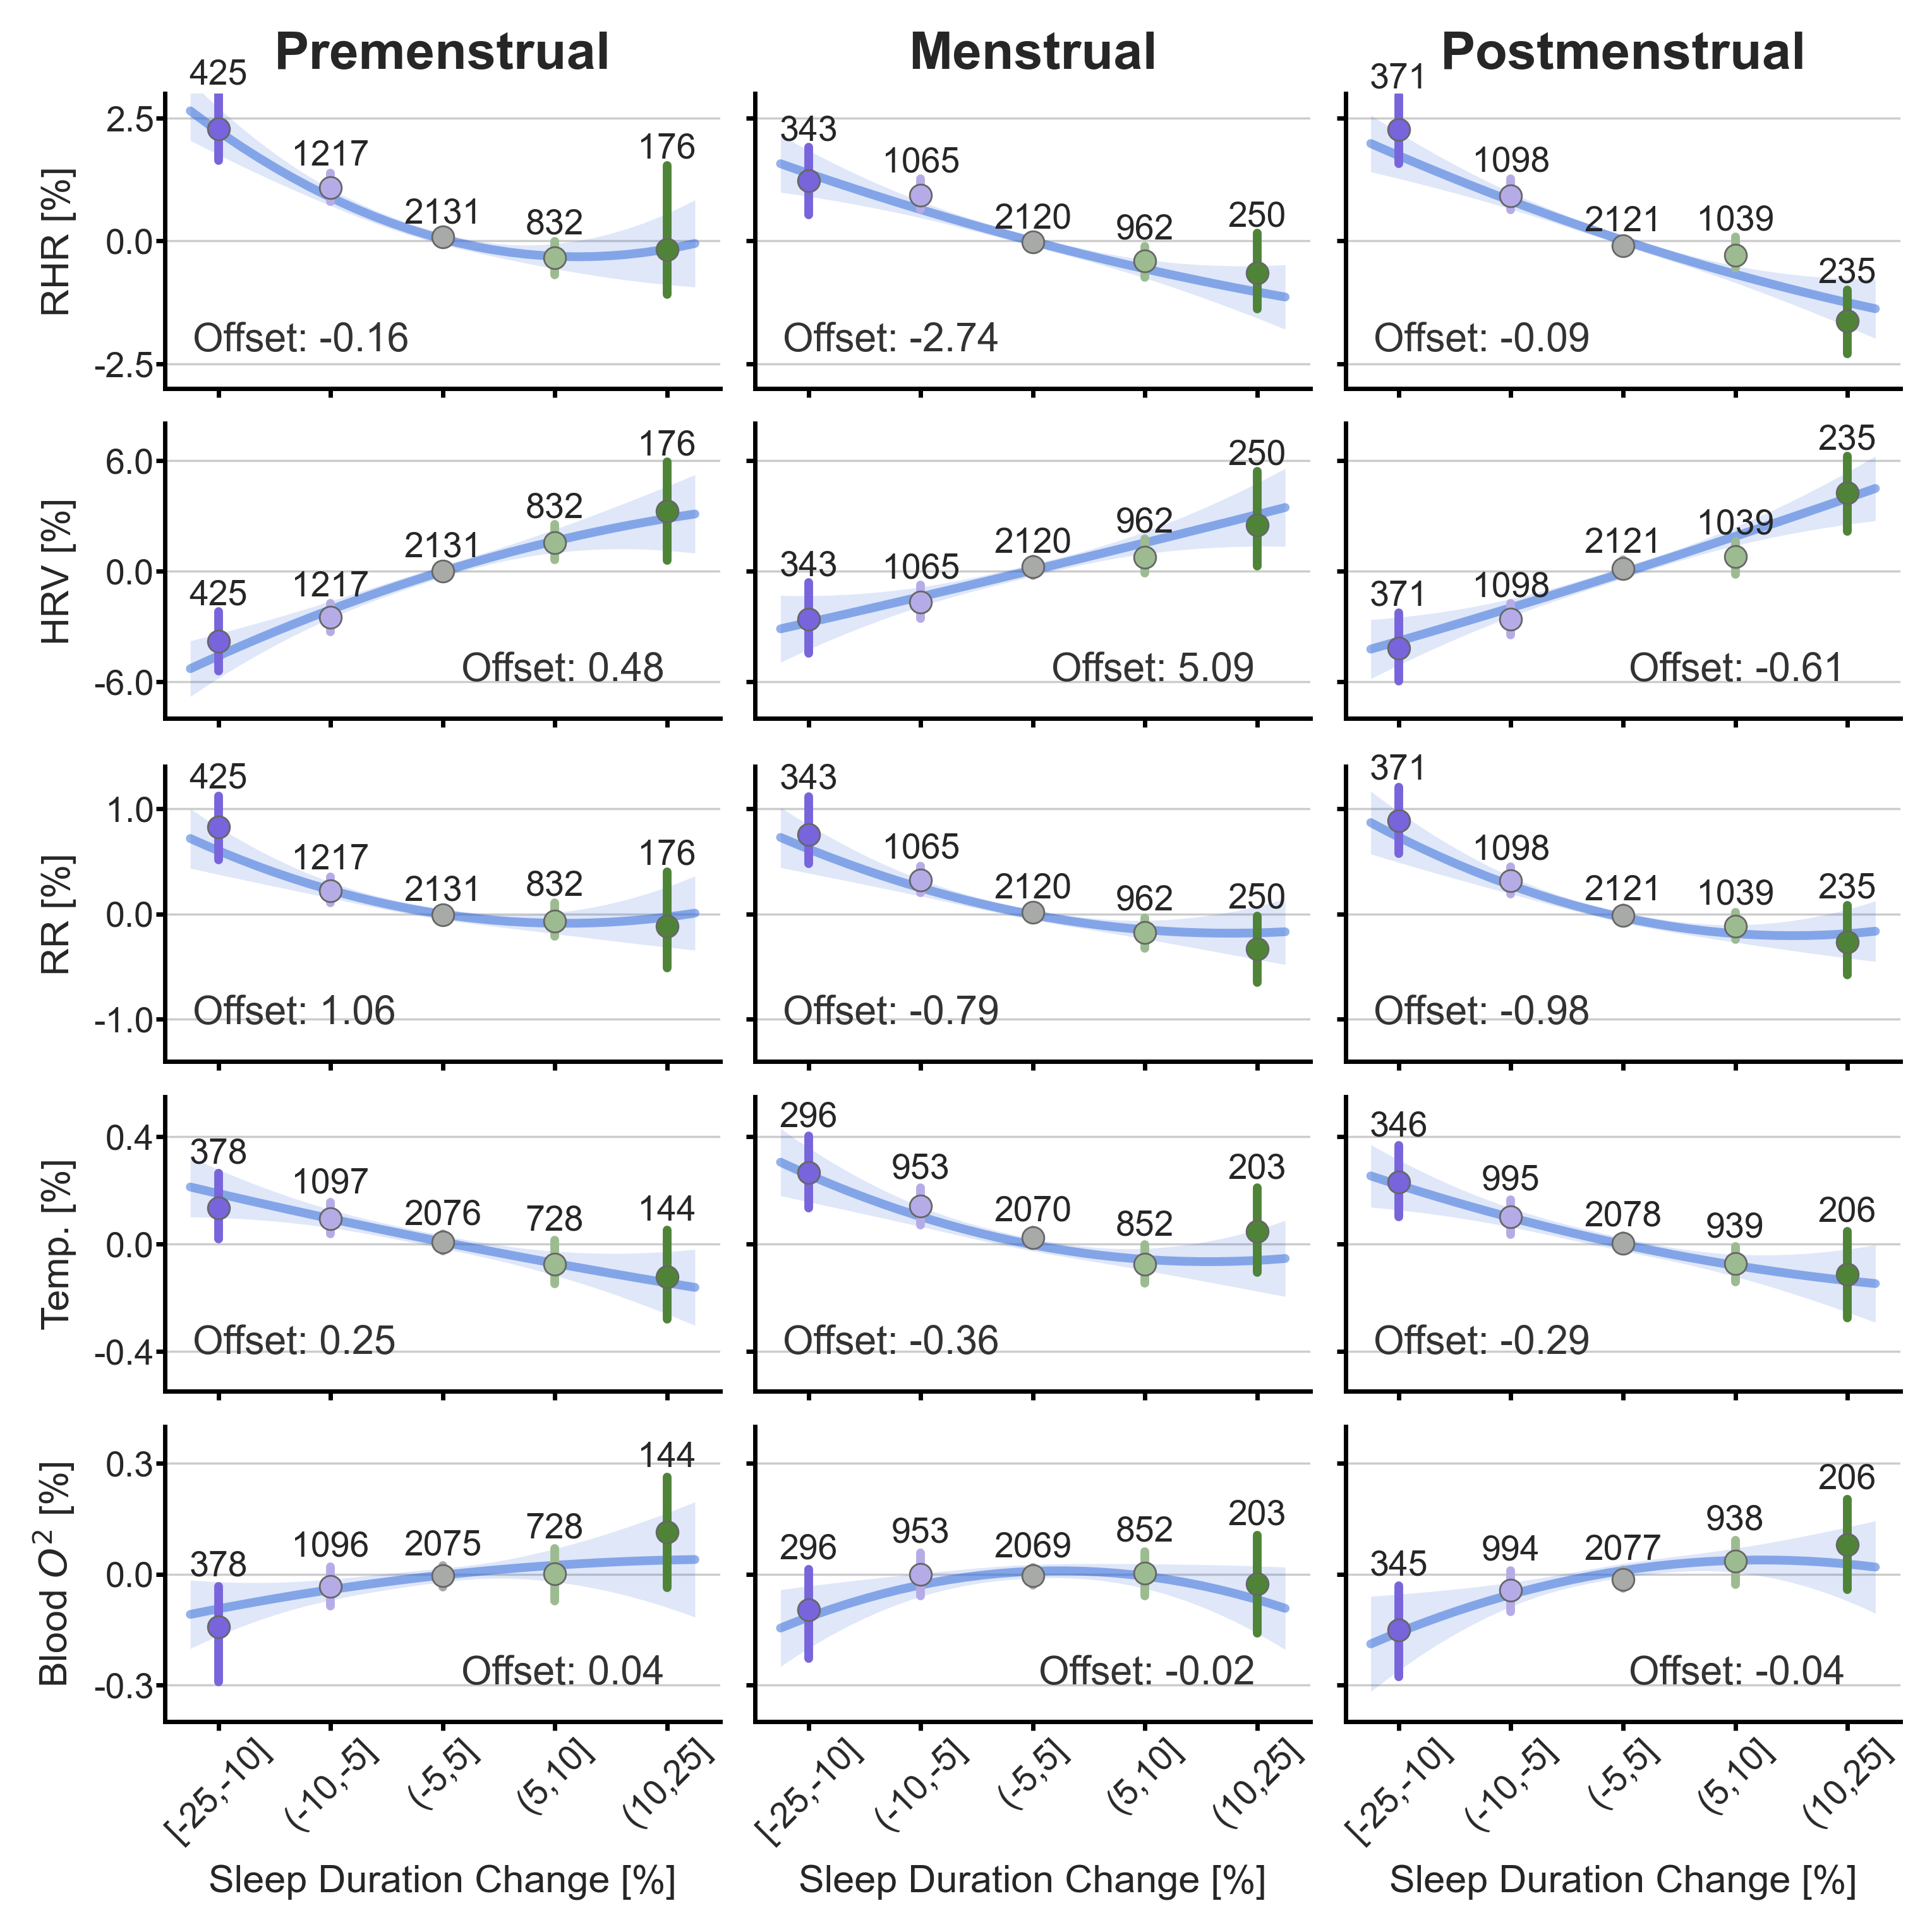

In [8]:
f, axes = PBA.plot_model_physio_response_x_phase_all(save=False)
plt.show()